In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [141]:
data = pd.read_csv(
    "data/100_Portfolios_10x10_Daily_valueweighted.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
19260701,-99.99,0.00,-99.99,1.59,-3.08,4.64,2.57,3.81,-0.52,-0.84,...,0.00,1.10,-0.15,-0.03,0.52,0.48,-0.43,-0.08,0.17,-99.99
19260702,-99.99,-0.27,-99.99,0.00,-0.97,-4.10,0.31,-0.47,2.74,-0.27,...,0.31,0.71,0.97,0.57,0.52,0.15,0.63,-0.04,0.34,-99.99
19260706,-99.99,1.01,-99.99,-4.69,2.35,-1.79,0.00,2.44,-5.18,-0.23,...,0.49,-0.19,0.89,0.31,-0.12,-0.18,-0.33,-0.40,-0.34,-99.99
19260707,-99.99,-1.67,-99.99,4.92,0.51,5.27,0.00,-0.74,-0.24,-0.02,...,-0.20,-0.01,0.66,0.38,0.03,0.25,-0.29,0.52,0.17,-99.99
19260708,-99.99,0.00,-99.99,1.56,-0.51,-1.06,0.00,4.90,0.45,0.26,...,0.56,-0.12,0.35,0.55,-0.14,0.19,-0.12,0.54,0.51,-99.99


In [142]:
data= data.replace(-99.99, np.nan)
data = data.replace(-999, np.nan)

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26110 entries, 19260701 to 20251031
Data columns (total 100 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SMALL LoBM  23562 non-null  float64
 1   ME1 BM2     23230 non-null  float64
 2   ME1 BM3     23208 non-null  float64
 3   ME1 BM4     24616 non-null  float64
 4   ME1 BM5     25171 non-null  float64
 5   ME1 BM6     25805 non-null  float64
 6   ME1 BM7     25813 non-null  float64
 7   ME1 BM8     26107 non-null  float64
 8   ME1 BM9     26110 non-null  float64
 9   SMALL HiBM  26110 non-null  float64
 10  ME2 BM1     23530 non-null  float64
 11  ME2 BM2     24323 non-null  float64
 12  ME2 BM3     25421 non-null  float64
 13  ME2 BM4     26102 non-null  float64
 14  ME2 BM5     25807 non-null  float64
 15  ME2 BM6     26110 non-null  float64
 16  ME2 BM7     26110 non-null  float64
 17  ME2 BM8     26110 non-null  float64
 18  ME2 BM9     26110 non-null  float64
 19  ME2 BM10    26110 n

In [144]:
data = data.fillna(0)
data = data / 100.0
data = data.astype(np.float32)
data.index = pd.to_datetime(data.index, format="%Y%m%d")

In [145]:
# print(data.min().min(), data.max().max())
# print(data.describe(percentiles=[0.001, 0.01, 0.99, 0.999]).T.sort_values("min").head(5))
# print(data.info())

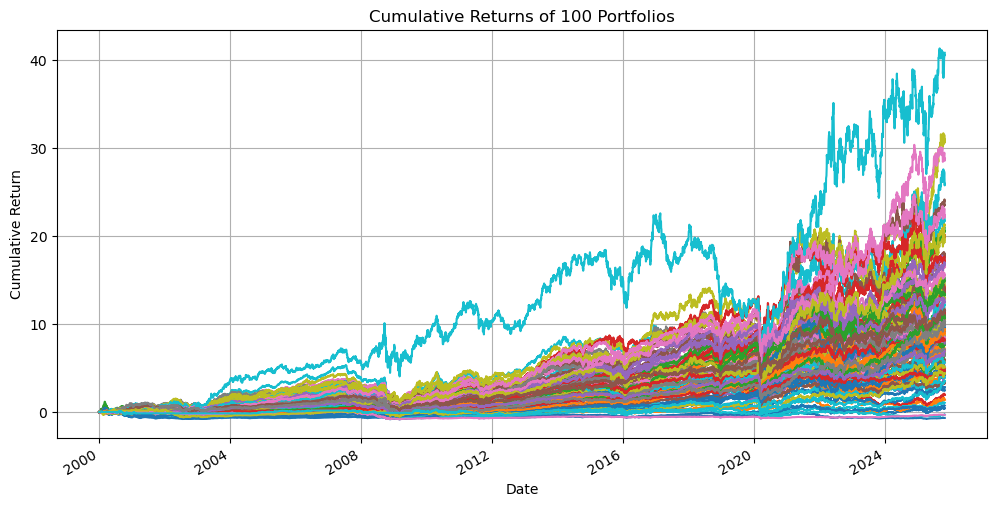

In [146]:
cum_returns = (1 + data.loc[data.index > "2000-01-01"]).cumprod() - 1
cum_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns of 100 Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.legend().set_visible(False)
plt.show()

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [147]:
from sklearn.model_selection import TimeSeriesSplit

max_years_lookback = 30

tscv_y = TimeSeriesSplit(n_splits=30, max_train_size=max_years_lookback*252, test_size=252)
tscv_q = TimeSeriesSplit(n_splits=20, max_train_size=max_years_lookback*252, test_size=63)
tscv_m = TimeSeriesSplit(n_splits=10, max_train_size=max_years_lookback*252, test_size=21)

tscv_init = TimeSeriesSplit(n_splits=5, max_train_size=max_years_lookback*252, test_size=252)

In [148]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

![image](images/1-s2.0-S0020025525003160-gr001.jpg)

In [149]:
class MLP(nn.Module):
    """
    Learn VAR(1) dynamics: p(z_t | z_{t-1}).
    """
    def __init__(self, z_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)
    
    def forward(self, z_prev):
        h = F.relu(self.fc1(z_prev))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [150]:
class Encoder(nn.Module):
    def __init__(self, W, D, z_dim, hidden_dim=128):
        super().__init__()
        in_dim = W * D
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, x):  # x: (B, W, D)
        h = F.relu(self.fc1(x.flatten(1)))
        return self.fc_mu(h), self.fc_logvar(h)


In [151]:
class DecoderGaussian(nn.Module):
    def __init__(self, D, z_dim, hidden_dim=128, min_logvar=-8.0, max_logvar=4.0):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, D) # output: single day, D portfolios
        self.fc_logvar = nn.Linear(hidden_dim, D)
        self.D = D
        self.min_logvar = min_logvar
        self.max_logvar = max_logvar

    def forward(self, z):  # z: (B, z_dim)
        h= F.relu(self.fc1(z))
        mu = self.fc_mu(h) # (B, D)
        logvar = self.fc_logvar(h) # (B, D)
        logvar = torch.clamp(logvar, self.min_logvar, self.max_logvar) 
        return mu, logvar

In [152]:
class VAE(nn.Module):
    def __init__(self, W, D, z_dim, hidden_dim=128):
        super().__init__()
        self.encoder = Encoder(W, D, z_dim, hidden_dim)
        self.decoder = DecoderGaussian(D, z_dim, hidden_dim)
        self.mlp = MLP(z_dim, hidden_dim=64)
        self.z_dim = z_dim
        self.W = W
        self.D = D

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, z_prev=None):
        """
        Forward pass.
        Args:
            x: (B, W, D) - W-day window
            z_prev: (B, z_dim) - previous latent state (or None)
        Returns:
            x_mu, x_logsigma: decoded single-day returns (B, D)
            z_mu_post, z_logvar_post: posterior q(z_t | x)
            z_mu_prior, z_logvar_prior: prior p(z_t | z_{t-1})
            z: sampled latent (B, z_dim)
        """
        # Encode current window -> posterior q(z_t | x_{t-W:t})
        z_mu_post, z_logvar_post = self.encoder(x)
        z = self.reparameterize(z_mu_post, z_logvar_post)

        # Decode z_t -> single day return
        x_mu, x_logsigma = self.decoder(z)

        # Prior from previous latent
        if z_prev is not None:
            z_mu_prior, z_logvar_prior = self.mlp(z_prev)
        else:
            # First timestep: use standard normal prior
            z_mu_prior = torch.zeros_like(z_mu_post)
            z_logvar_prior = torch.zeros_like(z_logvar_post)

        return x_mu, x_logsigma, z_mu_post, z_logvar_post, z_mu_prior, z_logvar_prior, z


In [ ]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
def kl_divergence(mu_post, logvar_post, mu_prior, logvar_prior):
   """
    KL divergence between two Gaussians:
    KL( N(mu_post, exp(logvar_post)) || N(mu_prior, exp(logvar_prior)) )
    """
   return 0.5 * (
        logvar_prior - logvar_post 
        + torch.exp(logvar_post) / torch.exp(logvar_prior)
        + ((mu_post - mu_prior) ** 2) / torch.exp(logvar_prior)
        - 1.0
    ).sum(dim=-1)



# TODO https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
def loss_fn(x_mu, x_logsigma, x_target, 
            z_mu_post, z_logvar_post, 
            z_mu_prior, z_logvar_prior, 
            beta=1.0):
    """
    VAE loss with temporal prior.
    Args:
        x_mu, x_logsigma: decoder outputs (B, D)
        x_target: true returns (B, D)
        z_mu_post, z_logvar_post: posterior parameters
        z_mu_prior, z_logvar_prior: prior parameters
        beta: KL weight for annealing
    Returns:
        total_loss, recon_loss, kl_loss
    """
    # Reconstruction loss (negative log-likelihood)
    recon = 0.5 * (
        x_logsigma 
        + ((x_target - x_mu) ** 2) / (2 * torch.exp(x_logsigma))
    ).sum(dim=1).mean()

    # KL divergence against conditional prior
    kl = kl_divergence(
        z_mu_post, z_logvar_post, 
        z_mu_prior, z_logvar_prior
    ).mean()

    total_loss = recon + beta * kl
    return total_loss, recon, kl

In [155]:
class Dataset(Dataset):
    def __init__(self, returns, window_size):
        super().__init__()
        self.returns = returns
        self.window_size = window_size
    
    def __len__(self):
        return len(self.returns) - self.window_size
    
    def __getitem__(self, idx):
        x_window = torch.FloatTensor(self.returns[idx:idx+self.window_size])  # (W, D)
        x_target = torch.FloatTensor(self.returns[idx+self.window_size])      # (D,)
        return x_window, x_target

In [ ]:
def train_vae(model, returns_train, W=50, epochs=50, lr=1e-3, device='cuda'):
    print(f"Training data shape: {returns_train.shape}")
    print(f"Model: z_dim={model.z_dim}, hidden_dim=256, device={device}")
    
    model = model.to(device).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataloader = DataLoader(Dataset(returns_train, W), batch_size=1, shuffle=False)
    
    n_samples = len(dataloader)
    print(f"Dataset: {n_samples} samples | {n_samples * epochs} total iterations")
    
    for epoch in range(epochs):
        z_prev = None
        epoch_loss, epoch_recon, epoch_kl = 0, 0, 0
        
        for batch_idx, (x_window, x_target) in enumerate(dataloader):
            x_window, x_target = x_window.to(device), x_target.to(device)
            
            optimizer.zero_grad()
            x_mu, x_logsigma, z_mu_post, z_logvar_post, z_mu_prior, z_logvar_prior, z = \
                model(x_window, z_prev)
            
            loss, recon, kl = loss_fn(x_mu, x_logsigma, x_target, 
                                      z_mu_post, z_logvar_post, z_mu_prior, z_logvar_prior, beta=1.0)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            z_prev = z.detach()
            
            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            
            if (batch_idx + 1) % 500 == 0:
                print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{n_samples}: "
                      f"Loss={loss.item():.4f}, Recon={recon.item():.4f}, KL={kl.item():.4f}")
        
        epoch_loss /= n_samples
        epoch_recon /= n_samples
        epoch_kl /= n_samples
        
        print(f"Epoch {epoch+1}/{epochs}: Loss={epoch_loss:.4f}, Recon={epoch_recon:.4f}, KL={epoch_kl:.4f}")
    
    return model
